# Value Iteration on MountainCar-v0

This notebook implements a **model-based** reinforcement learning solution for MountainCar using **value iteration**. The notebook is organized into three main parts:

1. **State Discretization** — The MountainCar environment has a continuous state space (position and velocity). We discretize it into a finite grid of bins so we can represent and update a tabular Q-table.
2. **MDP Estimation** — Since we do not have a closed-form model of the environment, we *discover* the transition dynamics and reward structure by running many random experiments (Monte Carlo sampling).
3. **Value Iteration** — Given the estimated MDP, we apply the Bellman optimality update iteratively until the Q-values converge, then extract and visualize the learned policy.

In [19]:
import numpy as np # used for arrays
import gymnasium as gym # pull the environment
from tqdm import tqdm # used for progress bar

## Environment Setup

Here we instantiate the MountainCar environment and inspect its action space.
`gym.make("MountainCar-v0")` loads the environment; `env.action_space.n` tells us how many discrete actions exist (3: push left, no push, push right).

In [20]:
env = gym.make("MountainCar-v0")
print(env.action_space.n)

3


Learning Parameters

In [21]:
gamma = 0.95
trials_per_state_action = 500  # number of random samples per (state, action) pair for MDP estimation

## Discretization: Mapping Continuous States to Discrete Bins

Many RL environments have **continuous** state spaces, but tabular methods like Q-learning require **discrete** integer indices. **Discretization** solves this by dividing each continuous dimension into equally-sized bins and mapping each value to a bin index.

**Formula:** `bin_index = floor((value - low) / bin_width)` where `bin_width = (high - low) / num_bins`

**Two important nuances to implement correctly:**

1. **Use `.astype(int)` (floor), not `np.round()`:**  
   `(value - low) / bin_width` produces a float like `26.67`. You want bin `26` — the bin the value *falls into* — not bin `27`. `.astype(int)` drops the decimal, which gives you the correct bin. Using `np.round()` would incorrectly push near-boundary values into the next bin.

2. **Clip to avoid an out-of-bounds index:**  
   When `value` is exactly at the upper boundary, the formula gives `index = num_bins`, which is one past the last valid index (`num_bins - 1`) and will cause an `IndexError`. Add one line after computing the bin index:
   ```python
   discrete_state = np.clip(discrete_state, 0, obs_bins - 1)
   ```

**Example** (MountainCar position dimension, 40 bins):
- MountainCar state space: position ∈ [-1.2, 0.6], velocity ∈ [-0.07, 0.07]
- `bin_width = (0.6 − (−1.2)) / 40 = 0.045`
- position = 0.0 → `(0.0 − (−1.2)) / 0.045 = 26.67` → **bin 26**
- position = 0.6 (max) → `1.8 / 0.045 = 40.0` → clip to **bin 39**

---

**Your Task:** The next three code cells set up the discretized state representation. Fill in the following:

1. **`obs_bins`** — Choose the number of bins for the position and velocity dimensions.
2. **`discrete_window_size`** — Compute the bin width for each dimension using the formula above.
3. **`q_shape`** — Define the shape of the Q-table as `(pos_bins, vel_bins, num_actions)`.
4. **`get_discrete_state(state)`** — Apply the discretization formula to map a continuous `[position, velocity]` state to integer bin indices.

In [22]:
# TODO: Replace None with the number of bins for each dimension of the state space.
# obs_bins should be a tuple (num_position_bins, num_velocity_bins).
obs_bins = (20, 20)

# TODO: Replace None with the bin width for each dimension.
# discrete_window_size is derived from the observation space range and the number of bins.
# Refer to the discretization formula in the markdown cell above.
discrete_window_size = (env.observation_space.high - env.observation_space.low) / np.array(obs_bins)

In [23]:
# TODO: Replace None with the correct shape for the Q-table.
# q_shape should be a tuple: (number of position bins, number of velocity bins, number of actions).
q_shape = (obs_bins[0], obs_bins[1], env.action_space.n)
q_table = np.random.uniform(low=0, high=1, size=q_shape)
q_shape

(20, 20, np.int64(3))

In [24]:
# TODO: Replace None with the discretized state.
# Use the discretization formula described in the markdown cell above to map
# the continuous state (position, velocity) to integer bin indices.
# Make sure to handle edge cases so indices stay within valid bounds.
def get_discrete_state(state):
    discrete_state = (np.array(state) - env.observation_space.low) / discrete_window_size
    discrete_state = np.clip(discrete_state, 0, np.array(obs_bins) - 1)
    return tuple(discrete_state.astype(int))

def get_continuous_state(state):
    # Converts a discrete bin index back to a continuous state value (center of the bin)
    return np.array(state) * discrete_window_size + env.observation_space.low

## Part 2: MDP Estimation

We estimate the transition model and reward function by interacting with the environment.
For each (state, action) pair, we sample `trials_per_state_action` transitions, recording
which state we land in and what reward we receive. This builds an empirical approximation
of the true MDP dynamics.

---

**Your Task:** Inside the sampling loop, after `env.step` returns, record the observed transition:

1. **`transition_counts`** — Increment by 1 for the observed `(state, action) → new_state` transition.
2. **`rewards`** — Accumulate the reward received for this transition.

In [25]:
transition_counts = np.zeros((q_shape[0], q_shape[1], env.action_space.n, q_shape[0], q_shape[1]))
rewards = np.zeros((q_shape[0], q_shape[1], env.action_space.n, q_shape[0], q_shape[1]))
for current_position in tqdm(range(q_shape[0])):
    for current_velocity in range(q_shape[1]):
        for action in range(env.action_space.n):
            for _ in range(trials_per_state_action):
                env.reset()
                continuous_state = get_continuous_state((current_position, current_velocity))
                # random within this bin
                continuous_state += np.random.uniform(0, discrete_window_size, size=2)

                env.unwrapped.state = continuous_state
                state, reward, done, _, _ = env.step(action)
                # We add a large bonus when the terminal state is reached so the agent has a
                # clear positive signal to work toward. Please keep this value as-is, but feel
                # free to experiment with different values and observe how the learned values
                # and optimal policy change!
                if done:
                    reward += 100
                new_state = get_discrete_state(state)

                # TODO: Update transition_counts and rewards for the observed transition.
                # TODO: Replace None with the appropriate increment (we observed one transition to new_state).
                transition_counts[current_position, current_velocity, action, new_state[0], new_state[1]] += 1
                # TODO: Replace None with the reward observed for this transition.
                rewards[current_position, current_velocity, action, new_state[0], new_state[1]] += reward


100%|██████████| 20/20 [00:10<00:00,  1.95it/s]


Plot discovered dynamics.

Text(0, 0.5, 'Destination Position Bin')

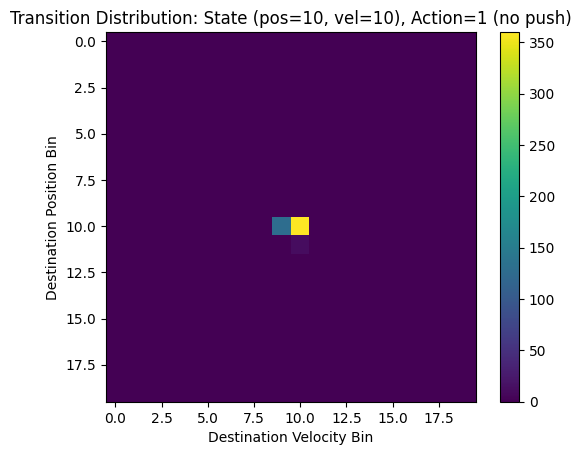

In [26]:
import matplotlib.pyplot as plt
# Change (10, 10) to inspect a different state bin; change action 1 to 0 or 2!
plt.imshow(transition_counts[10, 10, 1, :, :])
plt.colorbar()
plt.title("Transition Distribution: State (pos=10, vel=10), Action=1 (no push)")
plt.xlabel("Destination Velocity Bin")
plt.ylabel("Destination Position Bin")

**Interpretation:** Each cell in the heatmap represents how often a transition landed in that destination bin (out of `trials_per_state_action` trials). A bright, concentrated spot means the transition is nearly **deterministic** — the car reliably ends up in the same bin given this state and action. A spread means more stochasticity from sampling randomly within the source bin. MountainCar has nearly deterministic dynamics, so you should see tight clusters.

Let's visualize one state across actions to see all where we could end up:

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..423.0].


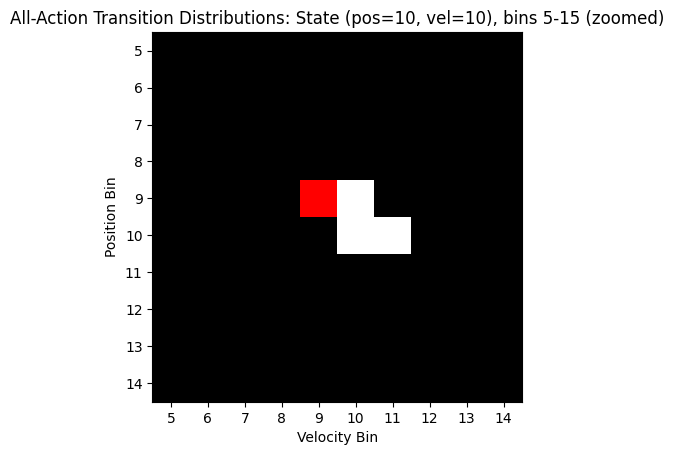

In [27]:
plt.imshow(transition_counts[10, 10, :, 5:15, 5:15].swapaxes(-1, 0))
plt.title("All-Action Transition Distributions: State (pos=10, vel=10), bins 5-15 (zoomed)")
plt.xlabel("Velocity Bin")
plt.ylabel("Position Bin")
plt.xticks(np.arange(10), np.arange(5, 15))
plt.yticks(np.arange(10), np.arange(5, 15))
_ = plt.plot()

**Interpretation:** This plot stacks the transition distributions for all 3 actions (push-left=0, no-push=1, push-right=2) at the same source state, zoomed to destination bins 5–15. Each colored stripe corresponds to one action.

Using our discovered dynamics:

Normalize rewards and convert our transition counts to probs.

In [28]:
transition_probs = transition_counts / trials_per_state_action
# Normalize rewards per-transition: average reward for each (s,a,s') pair
# Use safe division to avoid NaN where transition_counts is 0
rewards = np.divide(rewards, transition_counts, out=np.zeros_like(rewards), where=transition_counts != 0)
transition_probs.max(), transition_probs.min(), rewards.max(), rewards.min()

(np.float64(1.0), np.float64(0.0), np.float64(99.0), np.float64(-1.0))

## Value Iteration

Value iteration repeatedly applies the **Bellman optimality update** until Q-values converge:

$$Q(s, a) \leftarrow \sum_{s'} P(s'|s,a) \left[ R(s,a,s') + \gamma \cdot \max_{a'} Q(s', a') \right]$$

We track convergence via `delta` — the **maximum change** in any Q-value during one full sweep over all states. When `delta < theta` (1e-3), the values have stabilized and we stop.

**What to expect in the plot below:** `delta` should drop steeply in the first few iterations, then plateau near zero as values converge.

---

**Your Task:** Inside the Bellman update loop, fill in five values:

1. **`p`** — The transition probability for this `(state, action) → dest` pair.
2. **`r`** — The expected reward for this transition.
3. **`v`** — The discounted future value at the destination state (refer to the Bellman equation above).
4. **`q_table[pos, vel, action]`** — Set to the accumulated Bellman sum over all reachable destination states.
5. **`v_prime`** — The best Q-value at `(pos, vel)` after the update, used to compute `delta`.

In [29]:
theta = 1e-3  # convergence threshold
max_iterations = 2000
deltas = []

for iter_num in tqdm(range(max_iterations)):

    delta = 0

    # loop over all discrete states
    for pos in range(obs_bins[0]):
        for vel in range(obs_bins[1]):

            v_original = np.max(q_table[pos, vel, :])

            for action in range(env.action_space.n):
                dests = transition_probs[pos, vel, action, :, :].nonzero()

                q_value = 0
                for dest_pos, dest_vel in zip(*dests):
                    # TODO: Replace None with the transition probability P(dest | pos, vel, action)
                    p = transition_probs[pos, vel, action, dest_pos, dest_vel]
                    # TODO: Replace None with the expected reward R(pos, vel, action, dest) from the rewards array.
                    r = rewards[pos, vel, action, dest_pos, dest_vel]
                    # TODO: Replace None with the discounted future value at the destination state
                    #       (refer to the Bellman equation in the markdown cell above)
                    v = gamma * np.max(q_table[dest_pos, dest_vel])
                    q_value += p * (r + v)

                # TODO: Replace None with the computed q_value (accumulated Bellman sum over all reachable destinations)
                q_table[pos, vel, action] = q_value

            # TODO: Replace None with the best Q-value at this state after the update (used to measure convergence)
            v_prime = np.max(q_table[pos, vel])
            delta = max(delta, np.abs(v_prime - v_original))

    deltas.append(delta)
    if delta < theta:
        print("Converged at iteration", iter_num)
        break

print("Value iteration complete.")

  7%|▋         | 149/2000 [00:01<00:22, 81.03it/s]

Converged at iteration 149
Value iteration complete.


Text(0.5, 0, 'Iteration')

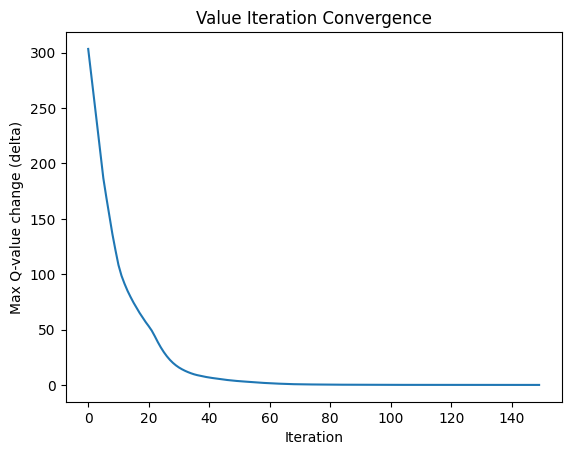

In [30]:
import matplotlib.pyplot as plt

plt.plot(deltas)
plt.title("Value Iteration Convergence")
plt.ylabel('Max Q-value change (delta)')
plt.xlabel('Iteration')

**Interpretation:** The plot shows the maximum change in any Q-value between consecutive iterations — this is how much the value estimates "moved" in that sweep. A steep initial drop followed by convergence to near-zero is the expected pattern.

Visualize Value

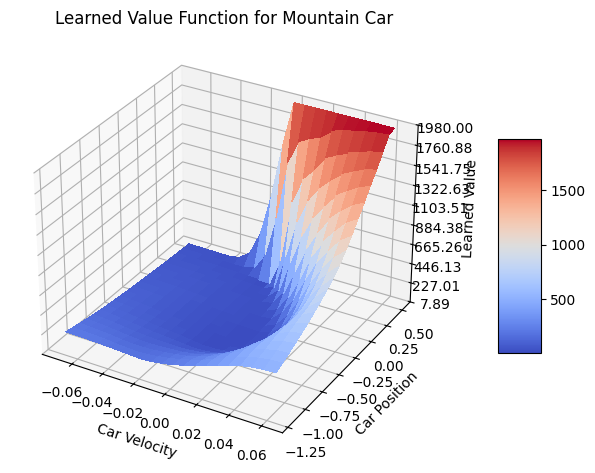

In [31]:
from matplotlib import cm
from matplotlib.ticker import LinearLocator

# max Q over possible actions
q_viz = q_table.max(axis=(-1))

fig, ax = plt.subplots(subplot_kw={'projection': '3d'})
X = np.arange(env.observation_space.low[1], env.observation_space.high[1], discrete_window_size[1])
Y = np.arange(env.observation_space.low[0], env.observation_space.high[0], discrete_window_size[0])
X, Y = np.meshgrid(X, Y)

# Plot the surface.
surf = ax.plot_surface(X, Y, q_viz, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

# Customize the z axis.
ax.set_zlim(np.min(q_viz), np.max(q_viz))
ax.zaxis.set_major_locator(LinearLocator(10))
# A StrMethodFormatter is used automatically
ax.zaxis.set_major_formatter('{x:.02f}')

ax.set_xlabel('Car Velocity')
ax.set_ylabel('Car Position')
ax.set_zlabel('Learned Value')
ax.set_title('Learned Value Function for Mountain Car')

# Add a color bar which maps values to colors.
# fig.set_size_inches(10, 8)
fig.colorbar(surf, shrink=0.5, aspect=5, pad=0.1)
fig.tight_layout()

plt.show()

## Extract Policy

**Your Task:** Derive the greedy policy from the converged Q-table:

- **`policy`** — A `(pos_bins, vel_bins)` array where each entry is the action with the highest Q-value for that state. Use `np.argmax`.

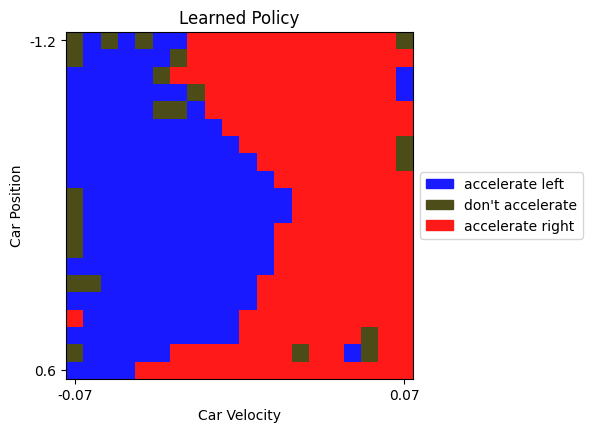

In [32]:
import matplotlib.patches as mpatches

# TODO: Replace None with the policy array.
# policy should be a (pos_bins, vel_bins) array where each entry is the best action
# (the one with the highest Q-value) for that state.
policy = np.argmax(q_table, axis=2)

# define cmap, patches and convert
cmap = {0:[0.1,0.1,1.0,1],1:[0.3,0.3,0.1,1],2:[1.0,0.1,0.1,1]}
labels = {0:'accelerate left',1:'don\'t accelerate',2:'accelerate right'}
p_viz = np.array([[cmap[policy[i,j]] for j in range(q_shape[1])] for i in range(q_shape[0])])
patches =[mpatches.Patch(color=cmap[i],label=labels[i]) for i in cmap]

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(p_viz)
plt.ylabel('Car Position')
plt.xlabel('Car Velocity')
plt.xticks([0, q_shape[1]-1],
           [env.observation_space.low[1], env.observation_space.high[1]])
plt.yticks([0, q_shape[0]-1],
           [env.observation_space.low[0], env.observation_space.high[0]])

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), handles=patches)

ax.set_title("Learned Policy")
fig.tight_layout()
plt.show()

## Use Policy (outputs a video, watch your agent play!)

**Your Task:** Fill in the action selection inside the evaluation loop:

- **`action`** — Select the greedy action for the current `discrete_state` from the learned Q-table. Use `np.argmax`.

In [33]:
from gymnasium.wrappers import RecordVideo
from datetime import datetime

test_env = gym.make("MountainCar-v0", render_mode="rgb_array")
test_env = RecordVideo(test_env, video_folder="./video", video_length=500, disable_logger=True,
                       name_prefix=f"value_iteration_{datetime.now().strftime('%Y%m%d_%H%M%S')}")

# play the game with the learned policy
done = False
truncated = False
discrete_state = get_discrete_state(test_env.reset()[0])
while not done and not truncated:
    # TODO: Replace None with the greedy action from the learned Q-table for the current discrete_state.
    action = np.argmax(q_table[discrete_state])
    new_state, reward, done, truncated, _ = test_env.step(action)
    discrete_state = get_discrete_state(new_state)

test_env.close()

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at f:\UMich\W26\EECS 492\Homework4\video folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
